# Evaluation and baselines

How to decide whether a forecast is *actually* good. The number from `r2_score` is where the
investigation starts, not where it ends.

Every section starts with a handful of numbers you can check by eye, then does the same on the real data.

**What's in here**
- naive baselines every model must beat
- each metric computed by hand on four numbers: RMSE, MAE, MAPE, sMAPE, MASE, R²
- single chronological split vs walk-forward refits
- in-sample vs out-of-sample
- where are the errors: by hour, month, regime; rolling RMSE
- is model B really better than A (Diebold–Mariano style)
- prediction intervals from residual quantiles and their coverage
- "R² improved after my change — does that prove it?"
- prices: statistical vs economic evaluation
- evaluation checklist

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## 0. Problem and frame

**Decision at τ − 24 h, predict consumption at target hour τ.** The frame is indexed by target
time; every feature is shifted by ≥ 24 so it was known at decision time. Train = 2022, test = 2023.

In [2]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).sort_values("time")
d = df.set_index("time")
y = d["consumption_mwh"]
F = pd.DataFrame({
    "y": y,
    "lag24": y.shift(24),                       # same hour yesterday = last value known at decision time
    "lag48": y.shift(48),
    "lag168": y.shift(168),                     # same hour last week
    "roll24": y.shift(24).rolling(24).mean(),   # mean of the 24 h ending at decision time
    "temp_lag24": d["temp_c"].shift(24),
    "hour": d.index.hour,
    "dow": d.index.dayofweek,
    "month": d.index.month,
})
F["hour_sin"] = np.sin(2 * np.pi * F["hour"] / 24)
F["hour_cos"] = np.cos(2 * np.pi * F["hour"] / 24)
F["is_weekend"] = (F["dow"] >= 5).astype(int)
F = F.dropna()
F.head(3)

,y,lag24,lag48,lag168,roll24,temp_lag24,hour,dow,month,hour_sin,hour_cos,is_weekend
time,,,,,,,,,,,,
2022-01-08 00:00:00+00:00,28210.5,28476.8,30808.0,26858.4,33787.558333,-1.24,0,5,1,0.000000,1.000000,1
2022-01-08 01:00:00+00:00,26205.3,28227.5,30059.8,26177.8,33711.212500,-2.17,1,5,1,0.258819,0.965926,1
2022-01-08 02:00:00+00:00,26127.0,28457.9,29282.1,26229.4,33676.870833,-2.67,2,5,1,0.500000,0.866025,1


In [3]:
train = F.loc[:"2022-12-31 23:00"]
test = F.loc["2023-01-01":]
print(len(train), "train rows |", len(test), "test rows")

8592 train rows | 8760 test rows


## 1. Naive baselines

If the model does not clearly beat these, it has learned nothing.

Toy: 8 hourly values with a repeating pattern of length 4 (think "4-hour day").

In [4]:
toy = pd.Series([10, 20, 30, 20, 12, 22, 32, 22], index=pd.date_range("2023-01-01", periods=8, freq="h"), name="y")
pd.DataFrame({
    "y": toy,
    "last value = shift(1)": toy.shift(1),
    "seasonal naive = shift(4)": toy.shift(4),
})

,y,last value = shift(1),seasonal naive = shift(4)
2023-01-01 00:00:00,10,NaN,NaN
2023-01-01 01:00:00,20,10.0,NaN
2023-01-01 02:00:00,30,20.0,NaN
2023-01-01 03:00:00,20,30.0,NaN
2023-01-01 04:00:00,12,20.0,10.0
2023-01-01 05:00:00,22,12.0,20.0
2023-01-01 06:00:00,32,22.0,30.0
2023-01-01 07:00:00,22,32.0,20.0


At 05:00 (value 22): "last value" predicts 12 (the 04:00 value); "seasonal naive" predicts 20
(the value one cycle earlier, at 01:00). The seasonal naive is much closer.

A third baseline: the mean by position-in-cycle, from the first half only (the "train" part).

In [5]:
pos = pd.Series(np.arange(8) % 4, index=toy.index, name="pos")
train_toy = toy.iloc[:4]
seasonal_mean = train_toy.groupby(pos.iloc[:4]).mean()
seasonal_mean

pos
0    10.0
1    20.0
2    30.0
3    20.0
Name: y, dtype: float64

In [6]:
pd.DataFrame({"y": toy, "pos": pos, "seasonal mean (from first half)": pos.map(seasonal_mean)})

,y,pos,seasonal mean (from first half)
2023-01-01 00:00:00,10,0,10.0
2023-01-01 01:00:00,20,1,20.0
2023-01-01 02:00:00,30,2,30.0
2023-01-01 03:00:00,20,3,20.0
2023-01-01 04:00:00,12,0,10.0
2023-01-01 05:00:00,22,1,20.0
2023-01-01 06:00:00,32,2,30.0
2023-01-01 07:00:00,22,3,20.0


**Pitfall:** the seasonal mean must be computed on train only, then mapped onto test. Now on the real data.

In [7]:
seasonal = train.groupby(["hour", "dow"])["y"].mean().rename("seasonal_mean")
base = pd.DataFrame({
    "same hour yesterday": test["lag24"],
    "same hour last week": test["lag168"],
    "seasonal mean (train)": test.join(seasonal, on=["hour", "dow"])["seasonal_mean"],
    "train mean (constant)": train["y"].mean(),
}, index=test.index)
base.head(3).round(0)

,same hour yesterday,same hour last week,seasonal mean (train),train mean (constant)
time,,,,
2023-01-01 00:00:00+00:00,26978.0,28713.0,24012.0,29348.0
2023-01-01 01:00:00+00:00,25950.0,27636.0,22846.0,29348.0
2023-01-01 02:00:00+00:00,25329.0,27406.0,22226.0,29348.0


## 2. Metrics, by hand first

Four actual values and four predictions.

In [8]:
y_true = np.array([10.0, 20.0, 30.0, 40.0])
y_pred = np.array([12.0, 18.0, 33.0, 37.0])
err = y_true - y_pred
pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "err": err, "err^2": err**2, "|err|": np.abs(err)})

,y_true,y_pred,err,err^2,|err|
0,10.0,12.0,-2.0,4.0,2.0
1,20.0,18.0,2.0,4.0,2.0
2,30.0,33.0,-3.0,9.0,3.0
3,40.0,37.0,3.0,9.0,3.0


In [9]:
print("RMSE =", np.sqrt(np.mean(err**2)))            # sqrt of the mean of err^2
print("MAE  =", np.mean(np.abs(err)))                # mean of |err|

RMSE = 2.5495097567963922
MAE  = 2.5


RMSE: (4 + 4 + 9 + 9) / 4 = 6.5, sqrt = 2.55. MAE: (2 + 2 + 3 + 3) / 4 = 2.5.
RMSE ≥ MAE always; the gap grows when a few errors are large.

**MAPE** divides each |err| by the actual value. It cannot be used when actuals are near zero or negative.

In [10]:
ape = np.abs(err) / np.abs(y_true)
print("APE per row :", ape.round(3))
print("MAPE        :", round(100 * ape.mean(), 2), "%")

APE per row : [0.2   0.1   0.1   0.075]
MAPE        : 11.88 %


**sMAPE** divides by the average of |actual| and |predicted| instead: bounded, still ugly near zero.

In [11]:
sape = 2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred))
print("sMAPE :", round(100 * sape.mean(), 2), "%")

sMAPE : 11.51 %


**MASE** = MAE / MAE of the naive forecast. Below 1 means better than naive. Scale-free, so
comparable across series. The naive here is "previous value".

In [12]:
naive_pred = np.array([np.nan, 10.0, 20.0, 30.0])       # previous value
naive_mae = np.nanmean(np.abs(y_true - naive_pred))
print("naive MAE :", naive_mae)
print("MASE      :", round(np.mean(np.abs(err)) / naive_mae, 3))

naive MAE : 10.0
MASE      : 0.25


**R²** = 1 − SSE / SST, where SST is the squared distance from the **mean of y_true**.

In [13]:
sse = np.sum(err**2)
sst = np.sum((y_true - y_true.mean())**2)
print("SSE :", sse, "| SST :", sst)
print("R2  :", round(1 - sse / sst, 4), "| sklearn:", round(r2_score(y_true, y_pred), 4))

SSE : 26.0 | SST : 500.0
R2  : 0.948 | sklearn: 0.948


**Pitfall:** out of sample, SST uses the *test* mean. Predicting the test mean (25) for every row gives
R² = 0 exactly; predicting the wrong level (50) makes SSE > SST, so **R² can be negative**.

In [14]:
const = np.full(4, 25.0)
print("R2 of predicting 25 everywhere :", round(r2_score(y_true, const), 4))
print("R2 of predicting 50 everywhere :", round(r2_score(y_true, np.full(4, 50.0)), 4))

R2 of predicting 25 everywhere : 0.0
R2 of predicting 50 everywhere : -5.0


Same computation packed into a function, then applied to the real baselines.

In [15]:
def metrics(y_true, y_pred, naive_mae):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    err = y_true - y_pred
    return pd.Series({
        "RMSE": np.sqrt(np.mean(err**2)),
        "MAE": np.mean(np.abs(err)),
        "MAPE_%": 100 * np.mean(np.abs(err / y_true)),
        "sMAPE_%": 100 * np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred))),
        "MASE": np.mean(np.abs(err)) / naive_mae,
        "R2": r2_score(y_true, y_pred),
        "bias": err.mean(),
    })

naive_mae_train = np.mean(np.abs(train["y"] - train["lag24"]))   # MASE scale, from TRAIN
results = pd.DataFrame({name: metrics(test["y"], col, naive_mae_train) for name, col in base.items()}).T
results.round(3)

,RMSE,MAE,MAPE_%,sMAPE_%,MASE,R2,bias
same hour yesterday,1695.799,1333.162,4.647,4.642,0.945,0.835,-1.647
same hour last week,1587.275,1236.283,4.320,4.302,0.876,0.855,-10.024
seasonal mean (train),2115.327,1790.646,6.331,6.282,1.269,0.743,-124.296
train mean (constant),4172.469,3375.742,12.253,11.746,2.392,-0.001,-124.395


The constant train mean has a **negative R²**: 2023 demand is lower than 2022's, so a 2022 constant is
worse than the 2023 mean. That is a statement about the level shift, not a bug.

## 3. Single split vs walk-forward

A single split fits once and predicts a whole year; by December the model is 12 months stale.
**Walk-forward** refits at the start of each block on everything before it.

Toy: 12 rows, blocks of 3, three folds.

In [16]:
rows = pd.Series(np.arange(1, 13), index=[f"r{i}" for i in range(1, 13)])
first_test = 3
for k in range(3):
    train_part = rows.iloc[: first_test + 3 * k]
    test_part = rows.iloc[first_test + 3 * k: first_test + 3 * (k + 1)]
    print(f"fold {k}: train = {list(train_part.index)}   test = {list(test_part.index)}")

fold 0: train = ['r1', 'r2', 'r3']   test = ['r4', 'r5', 'r6']
fold 1: train = ['r1', 'r2', 'r3', 'r4', 'r5', 'r6']   test = ['r7', 'r8', 'r9']
fold 2: train = ['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9']   test = ['r10', 'r11', 'r12']


Each fold's training set ends exactly where its test block starts, and grows by one block per fold.
Concatenating the three test predictions gives one out-of-sample prediction for r4 … r12.

Real data: monthly refit on an expanding window.

In [17]:
features = ["lag24", "lag48", "lag168", "roll24", "temp_lag24", "hour_sin", "hour_cos", "is_weekend"]

m_single = LinearRegression().fit(train[features], train["y"])
pred_single = pd.Series(m_single.predict(test[features]), index=test.index, name="LR single split")

In [18]:
def walk_forward(cols, window_days=None):
    preds = []
    for month_start in pd.date_range("2023-01-01", "2023-12-01", freq="MS", tz="UTC"):
        month_end = month_start + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23)
        tr = F.loc[: month_start - pd.Timedelta(hours=1)]       # strictly before the month
        if window_days is not None:
            tr = tr.iloc[-24 * window_days:]                     # rolling window instead of expanding
        te = F.loc[month_start: month_end]
        m = LinearRegression().fit(tr[cols], tr["y"])
        preds.append(pd.Series(m.predict(te[cols]), index=te.index))
    return pd.concat(preds)

pred_wf = walk_forward(features).rename("LR walk-forward monthly")
print("walk-forward rows:", len(pred_wf), "| same index as test:", pred_wf.index.equals(test.index))

walk-forward rows: 8760 | same index as test: True


In [19]:
models = pd.concat([base, pred_single, pred_wf], axis=1)
results = pd.DataFrame({name: metrics(test["y"], col, naive_mae_train) for name, col in models.items()}).T
results.round(3).sort_values("RMSE")

,RMSE,MAE,MAPE_%,sMAPE_%,MASE,R2,bias
LR single split,1190.281,946.680,3.318,3.299,0.671,0.919,-72.256
LR walk-forward monthly,1190.851,947.852,3.320,3.304,0.672,0.918,-51.756
same hour last week,1587.275,1236.283,4.320,4.302,0.876,0.855,-10.024
same hour yesterday,1695.799,1333.162,4.647,4.642,0.945,0.835,-1.647
seasonal mean (train),2115.327,1790.646,6.331,6.282,1.269,0.743,-124.296
train mean (constant),4172.469,3375.742,12.253,11.746,2.392,-0.001,-124.395


**Interview check:** "Is the gap between train and test large enough?" With h = 24 the last training
*target* (2022-12-31 23:00) is after the first test *decision* (2022-12-31 00:00). Strictly, drop the
last 24 training rows. It rarely changes the number; knowing it does.

## 4. In-sample vs out-of-sample

In-sample R² can only go **up** when you add a feature, even pure noise. Out of sample it goes down.

Only the last 300 training hours, with and without 20 columns of pure noise.

In [20]:
rng = np.random.default_rng(0)
noise_cols = [f"noise{i}" for i in range(20)]
for c in noise_cols:
    F[c] = rng.normal(size=len(F))
train = F.loc[:"2022-12-31 23:00"]
test = F.loc["2023-01-01":]
small = train.iloc[-300:]                       # only the last 300 training hours

In [21]:
for label, cols in [("real features", features), ("real + 20 noise", features + noise_cols)]:
    m = LinearRegression().fit(small[cols], small["y"])
    print(f"{label:16s} in-sample R2 = {r2_score(small['y'], m.predict(small[cols])):.4f}   "
          f"out-of-sample R2 = {r2_score(test['y'], m.predict(test[cols])):.4f}")

real features    in-sample R2 = 0.8876   out-of-sample R2 = 0.6245
real + 20 noise  in-sample R2 = 0.8960   out-of-sample R2 = 0.6166


The noise columns raise the in-sample number and lower the out-of-sample one. Whoever shows you an
in-sample improvement has shown you nothing.

## 5. Where are the errors? Decompose before you conclude

One RMSE hides structure. Group the error by hour, month, regime.

Toy: six errors with an hour label. The overall mean is zero; by hour it is not.

In [22]:
e_toy = pd.DataFrame({"hour": [6, 6, 6, 18, 18, 18], "err": [-5, -3, -4, 5, 3, 4]})
print("overall mean error :", e_toy["err"].mean())
e_toy.groupby("hour")["err"].mean()

overall mean error : 0.0


hour
6    -4.0
18    4.0
Name: err, dtype: float64

"No bias" overall, −4 at 06:00 and +4 at 18:00: the model is systematically wrong in opposite directions.
Positive error = model under-predicts.

In [23]:
ev = test[["y", "hour", "dow", "month", "temp_lag24"]].copy()
ev["pred"] = pred_wf
ev["err"] = ev["y"] - ev["pred"]
ev.groupby("hour")["err"].mean().round(0).to_frame("bias by hour").T

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
bias by hour,-108.0,-133.0,-131.0,-137.0,-137.0,-95.0,-4.0,101.0,140.0,99.0,38.0,-45.0,-131.0,-214.0,-256.0,-252.0,-129.0,38.0,128.0,101.0,48.0,-2.0,-65.0,-96.0


In [24]:
ev.groupby("month")["err"].mean().round(0).to_frame("bias by month").T

month,1,2,3,4,5,6,7,8,9,10,11,12
bias by month,215.0,-31.0,-83.0,-375.0,-296.0,-186.0,137.0,41.0,-93.0,4.0,24.0,9.0


In [25]:
ev["regime"] = pd.cut(ev["temp_lag24"], [-99, 0, 10, 20, 99], labels=["<0C", "0-10C", "10-20C", ">20C"])
g = ev.groupby("regime", observed=True)["err"]
pd.DataFrame({"n": g.size(), "bias": g.mean(), "rmse": np.sqrt((ev["err"]**2).groupby(ev["regime"], observed=True).mean())}).round(0)

,n,bias,rmse
regime,,,
<0C,536,116.0,1379.0
0-10C,3911,-69.0,1238.0
10-20C,3744,-121.0,1144.0
>20C,569,362.0,942.0


## 6. Error over time: rolling RMSE

Is performance stable, or does one bad fortnight drive the annual number?

Toy: six errors, RMSE over a window of 3.

In [26]:
e = pd.Series([1.0, 1.0, 1.0, 10.0, 1.0, 1.0])
pd.DataFrame({"err": e, "err^2": e**2, "rolling3 mean of err^2": (e**2).rolling(3).mean(), "rolling RMSE": np.sqrt((e**2).rolling(3).mean())})

,err,err^2,rolling3 mean of err^2,rolling RMSE
0,1.0,1.0,NaN,NaN
1,1.0,1.0,NaN,NaN
2,1.0,1.0,1.0,1.000000
3,10.0,100.0,34.0,5.830952
4,1.0,1.0,34.0,5.830952
5,1.0,1.0,34.0,5.830952


One error of 10 lifts the rolling RMSE to about 5.9 for three windows, then it falls back to 1.

worst 14-day window ends: 2023-05-06 03:00:00+00:00 | RMSE: 1616


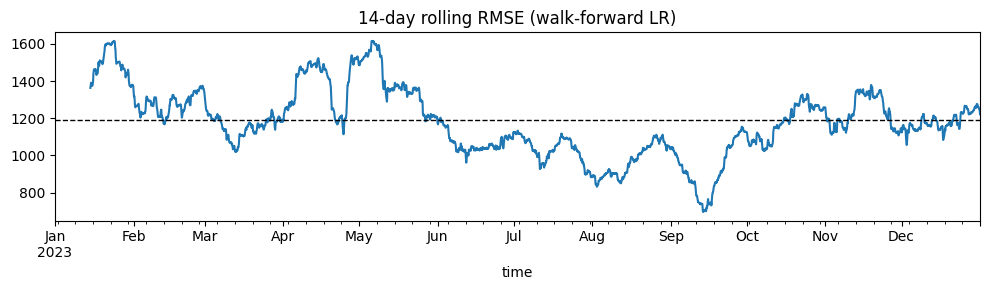

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
roll_rmse = np.sqrt((ev["err"]**2).rolling(24 * 14).mean())
ax = roll_rmse.plot(figsize=(10, 3), title="14-day rolling RMSE (walk-forward LR)")
ax.axhline(np.sqrt((ev["err"]**2).mean()), color="k", ls="--", lw=1)
plt.tight_layout()
print("worst 14-day window ends:", roll_rmse.idxmax(), "| RMSE:", round(roll_rmse.max()))

## 7. Is model B really better than model A? (Diebold–Mariano style)

Per row, `d = e_A² − e_B²`. If B is better, mean(d) > 0. Then a t-statistic: mean / standard error.

Toy: five paired errors.

In [28]:
e_A = np.array([3.0, -2.0, 4.0, -3.0, 2.0])
e_B = np.array([1.0, -1.0, 3.0, -2.0, 1.0])
dd = e_A**2 - e_B**2
pd.DataFrame({"e_A": e_A, "e_B": e_B, "e_A^2": e_A**2, "e_B^2": e_B**2, "d": dd})

,e_A,e_B,e_A^2,e_B^2,d
0,3.0,1.0,9.0,1.0,8.0
1,-2.0,-1.0,4.0,1.0,3.0
2,4.0,3.0,16.0,9.0,7.0
3,-3.0,-2.0,9.0,4.0,5.0
4,2.0,1.0,4.0,1.0,3.0


In [29]:
print("mean(d)  :", dd.mean())
print("sd(d)    :", round(dd.std(ddof=1), 3))
print("se       :", round(dd.std(ddof=1) / np.sqrt(len(dd)), 3))
print("t (iid)  :", round(dd.mean() / (dd.std(ddof=1) / np.sqrt(len(dd))), 2))

mean(d)  : 5.2
sd(d)    : 2.28
se       : 1.02
t (iid)  : 5.1


|t| > 2 is the rule of thumb for "B is better". But hourly errors are **autocorrelated**, and the iid
standard error is then too small. A Newey–West standard error adds the covariance at lags 1..L.

In [30]:
def nw_se(x, lags):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    v = np.mean(x**2)
    for k in range(1, lags + 1):
        w = 1 - k / (lags + 1)
        v += 2 * w * np.mean(x[:-k] * x[k:])
    return np.sqrt(v / n)

def dm_test(e_a, e_b, lags=24):
    dd = np.asarray(e_a)**2 - np.asarray(e_b)**2
    return pd.Series({"mean_d": dd.mean(),
                      "t_iid": dd.mean() / (dd.std(ddof=1) / np.sqrt(len(dd))),
                      "t_HAC": dd.mean() / nw_se(dd, lags)})

pd.DataFrame({
    "same hour yesterday vs LR": dm_test(test["y"] - test["lag24"], test["y"] - pred_wf),
    "last week vs LR": dm_test(test["y"] - test["lag168"], test["y"] - pred_wf),
    "single-split vs walk-forward": dm_test(test["y"] - pred_single, test["y"] - pred_wf),
}).T.round(2)

,mean_d,t_iid,t_HAC
same hour yesterday vs LR,1457607.60,34.51,11.66
last week vs LR,1101315.24,32.41,10.46
single-split vs walk-forward,-1356.86,-0.90,-0.33


`t_iid` is much larger than `t_HAC`: autocorrelation inflates it. For the small edge
(single split vs walk-forward) the honest test says "cannot tell".

## 8. Prediction intervals from residual quantiles

Take the 5th and 95th percentile of the **training** residuals, add them to the prediction, and
check what share of test actuals falls inside (coverage). Nominal 90 % should give about 90 %.

Toy: six training residuals, one test row.

In [31]:
resid = pd.Series([-3.0, -1.0, 0.0, 1.0, 2.0, 4.0])
q_lo, q_hi = resid.quantile([0.05, 0.95])
print("residual quantiles 5% / 95% :", q_lo, "/", q_hi)

residual quantiles 5% / 95% : -2.5 / 3.5


In [32]:
pred_toy = pd.Series([100.0, 100.0, 100.0])
actual_toy = pd.Series([98.0, 105.0, 101.0])
lo, hi = pred_toy + q_lo, pred_toy + q_hi
pd.DataFrame({"pred": pred_toy, "lo": lo, "hi": hi, "actual": actual_toy, "covered": (actual_toy >= lo) & (actual_toy <= hi)})

,pred,lo,hi,actual,covered
0,100.0,97.5,103.5,98.0,True
1,100.0,97.5,103.5,105.0,False
2,100.0,97.5,103.5,101.0,True


105 falls outside [97.5, 103.5]: coverage 2 of 3. On the real data:

In [33]:
resid_train = train["y"] - m_single.predict(train[features])
q_lo, q_hi = resid_train.quantile([0.05, 0.95])
lo, hi = pred_single + q_lo, pred_single + q_hi
covered = (test["y"] >= lo) & (test["y"] <= hi)
print(f"interval = pred + [{q_lo:.0f}, {q_hi:.0f}]   nominal 90%   test coverage {covered.mean():.1%}")

interval = pred + [-1975, 1944]   nominal 90%   test coverage 90.1%


In [34]:
covered.groupby(test["month"]).mean().round(2).to_frame("coverage by month").T

month,1,2,3,4,5,6,7,8,9,10,11,12
coverage by month,0.84,0.87,0.92,0.8,0.89,0.93,0.95,0.96,0.96,0.89,0.89,0.9


Coverage far from 90 % in some months means the intervals are lying there (the single-split model is stale).

## 9. "R² improved after my change — does that prove it?"

No. Ask: how many things did I try? Is one period driving it? Is there a mechanism?

Toy: model B beats A on the annual number but only because of one month.

In [35]:
monthly_toy = pd.DataFrame({"A": [100, 100, 100, 100], "B": [105, 105, 105, 60]}, index=["Jan", "Feb", "Mar", "Apr"])
monthly_toy["B wins"] = monthly_toy["B"] < monthly_toy["A"]
print(monthly_toy)
print("annual mean RMSE  A:", monthly_toy["A"].mean(), " B:", monthly_toy["B"].mean())
print("B wins", monthly_toy["B wins"].sum(), "of 4 months")

       A    B  B wins
Jan  100  105   False
Feb  100  105   False
Mar  100  105   False
Apr  100   60    True
annual mean RMSE  A: 100.0  B: 93.75
B wins 1 of 4 months


B is "better" on the annual number and worse in 3 months out of 4. Real data: three variants, per month.

In [36]:
pred_A = walk_forward([c for c in features if c != "temp_lag24"])   # A: no temperature
pred_B = pred_wf                                                     # B: with temp_lag24
pred_C = walk_forward(features, window_days=30)                      # C: B on only the last 30 days

def rmse(e):
    return np.sqrt(np.mean(e**2))

monthly = pd.DataFrame({
    "A: no temp": (test["y"] - pred_A).groupby(test["month"]).apply(rmse),
    "B: + temp_lag24": (test["y"] - pred_B).groupby(test["month"]).apply(rmse),
    "C: B, 30-day window": (test["y"] - pred_C).groupby(test["month"]).apply(rmse),
}).round(0)
monthly["B beats A"] = monthly["B: + temp_lag24"] < monthly["A: no temp"]
monthly["C beats B"] = monthly["C: B, 30-day window"] < monthly["B: + temp_lag24"]
monthly

,A: no temp,B: + temp_lag24,"C: B, 30-day window",B beats A,C beats B
month,,,,,
1,1571.0,1378.0,1616.0,True,False
2,1398.0,1287.0,1457.0,True,False
3,1150.0,1140.0,1153.0,True,False
4,1615.0,1490.0,1777.0,True,False
5,1296.0,1272.0,1399.0,True,False
6,1050.0,1082.0,1064.0,False,True
7,954.0,952.0,895.0,True,True
8,1019.0,1000.0,941.0,True,True
9,1015.0,947.0,966.0,True,False


In [37]:
print("B beats A in", monthly["B beats A"].sum(), "of 12 months | C beats B in", monthly["C beats B"].sum(), "of 12")
print("annual RMSE  A %.0f   B %.0f   C %.0f" % (rmse(test["y"] - pred_A), rmse(test["y"] - pred_B), rmse(test["y"] - pred_C)))

B beats A in 11 of 12 months | C beats B in 4 of 12
annual RMSE  A 1255   B 1191   C 1293


B (a feature with a mechanism: heating) wins consistently. C wins some months and loses badly in others.

**Pitfall:** dropping one bad month and re-running until it looks nice *is* the multiple-comparisons problem.

## 10. Prices: statistical vs economic evaluation

For prices MAPE breaks, and the question changes from "how close" to "would acting on it have made money".

Toy: two prices, one near zero.

In [38]:
p_true = np.array([1.0, 100.0])
p_pred = np.array([2.0, 90.0])
ape = np.abs(p_true - p_pred) / np.abs(p_true)
print("APE per row :", ape)
print("MAPE        :", 100 * ape.mean(), "%")

APE per row : [1.  0.1]
MAPE        : 55.00000000000001 %


A 1 EUR miss on a 1 EUR price is 100 %; a 10 EUR miss on 100 is 10 %. MAPE = 55 %, driven by the near-zero row.

In [39]:
p = d["price_eur_mwh"]
P = pd.DataFrame({
    "y": p, "p_lag24": p.shift(24), "p_lag48": p.shift(48), "p_lag168": p.shift(168),
    "p_roll24": p.shift(24).rolling(24).mean(),
    "cons_lag24": y.shift(24), "wind_lag24": d["wind_ms"].shift(24),
    "hour_sin": np.sin(2 * np.pi * d.index.hour / 24), "hour_cos": np.cos(2 * np.pi * d.index.hour / 24),
    "is_weekend": (d.index.dayofweek >= 5).astype(int),
}).dropna()
ptrain, ptest = P.loc[:"2022-12-31 23:00"], P.loc["2023-01-01":].copy()
pcols = [c for c in P.columns if c != "y"]
pm = Ridge(alpha=1.0).fit(ptrain[pcols], ptrain["y"])
ptest["pred"] = pm.predict(ptest[pcols])
ptest["err"] = ptest["y"] - ptest["pred"]

naive_p_mae = np.mean(np.abs(ptrain["y"] - ptrain["p_lag24"]))
pd.DataFrame({"naive lag24": metrics(ptest["y"], ptest["p_lag24"], naive_p_mae),
              "Ridge": metrics(ptest["y"], ptest["pred"], naive_p_mae)}).T.round(2)

,RMSE,MAE,MAPE_%,sMAPE_%,MASE,R2,bias
naive lag24,28.36,20.20,41.34,27.63,1.00,0.33,-0.04
Ridge,23.52,17.17,42.01,22.90,0.85,0.54,-4.38


Ridge wins on RMSE, MAE and MASE but has a *worse* MAPE. Which rows cause that?

In [40]:
ape = 100 * np.abs(ptest["err"] / ptest["y"])
smallest = ptest["y"].abs().sort_values().index[:5]
pd.DataFrame({"price": ptest["y"], "pred": ptest["pred"], "APE_%": ape}).loc[smallest].round(1)

,price,pred,APE_%
time,,,
2023-03-12 08:00:00+00:00,-0.4,97.9,22872.4
2023-09-29 23:00:00+00:00,0.5,66.7,12476.5
2023-07-10 14:00:00+00:00,-0.6,52.5,9155.7
2023-10-26 00:00:00+00:00,-0.8,80.7,10722.6
2023-06-20 22:00:00+00:00,-0.8,76.6,9215.8


In [41]:
print("MAPE all rows                    : %.1f%%" % ape.mean())
print("MAPE without 10 smallest |price| : %.1f%%" % ape.drop(ptest["y"].abs().sort_values().index[:10]).mean())
print("median APE                       : %.1f%%" % ape.median())

MAPE all rows                    : 42.0%
MAPE without 10 smallest |price| : 32.6%
median APE                       : 16.3%


**Directional accuracy:** did we get the sign of the change since yesterday right? Compare to a coin (50 %).

In [42]:
actual_chg = ptest["y"] - ptest["p_lag24"]
pred_chg = ptest["pred"] - ptest["p_lag24"]
print("directional accuracy :", round((np.sign(actual_chg) == np.sign(pred_chg)).mean(), 3))

directional accuracy : 0.675


**Toy economic test.** Trade in the predicted direction when the predicted change exceeds 15;
P&L per trade = sign × actual change. Compare with random signs on the same hours.

This is a toy: no costs, no volume, and day-ahead prices are not tradable like this. The point is the method.

In [43]:
trade = pred_chg.abs() > 15
pnl = np.sign(pred_chg[trade]) * actual_chg[trade]
print("trades          :", trade.sum())
print("hit rate        :", round((pnl > 0).mean(), 3))
print("mean P&L/trade  :", round(pnl.mean(), 2))
print("total P&L       :", round(pnl.sum()))

trades          : 2824
hit rate        : 0.822
mean P&L/trade  : 21.36
total P&L       : 60314


In [44]:
rng = np.random.default_rng(1)
random_totals = np.array([(rng.choice([-1, 1], trade.sum()) * actual_chg[trade]).sum() for _ in range(2000)])
print("random-sign totals: mean %.0f, sd %.0f" % (random_totals.mean(), random_totals.std()))
print("model total is %.1f sd above random" % ((pnl.sum() - random_totals.mean()) / random_totals.std()))
print("share of P&L from the 10 best trades: %.0f%%" % (100 * pnl.nlargest(10).sum() / pnl.sum()))

random-sign totals: mean -29, sd 1945
model total is 31.0 sd above random
share of P&L from the 10 best trades: 4%


Synthetic data with a very regular price process, so the numbers are absurdly good — read the procedure, not the result.

**Interview check:** "What would kill this in practice?" → costs vs mean P&L per trade, P&L concentrated
in a few spike hours, fit on the 2022 regime, no position sizing.

## 11. Evaluation checklist

1. Did I compare with **naive baselines**? By how much do I beat them, and is that within noise?
2. Is the split **chronological**, with a **gap ≥ h**? Long enough to cover seasons and regimes?
3. Do I report **out-of-sample** numbers? What is the in-sample vs OOS gap?
4. Is the metric right for the **scale and sign** of the target (MAPE near zero, R² with a level shift)?
5. **Where** are the errors: by hour, weekday, month, regime? Any systematic **bias** in a group?
6. Is the error **stable over time**, or is one period driving the annual number?
7. Comparing two models: **significant** with an autocorrelation-aware test? Does B win **most sub-periods**?
8. **How many variants** did I try before this one?
9. Does the improvement have a **mechanism**?
10. Are prediction intervals **calibrated** (coverage ≈ nominal)?
11. For trading: economic evaluation vs random, costs, concentration, regime dependence.
12. Would I be comfortable if this number were **worse tomorrow**? If not, I have not understood it.